#### Projeto Integrador III – Sprint 03: Testagem e Comparação de Modelos PLN
###### **Alunos**: Maria Eduarda da Cruz | Yghor Kristian Andrade | **Orientador:** Rômulo Francisco de Souza
**Objetivo:** Realizar a seleção e testagem de modelos, a fim de analisar e comparar seu desempenho para determinar qual adequado ao escopo do projeto.

**Dataset:** A escolha do dataset TweetSentBR se deu devido a fácil acessibilidade e treinamento, apesar de não ser exclusivamente sobre debates políticos. 

##### 01. Instalando bibliotecas 

In [11]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


^C
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cpu



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
%pip install sentencepiece protobuf


   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 16.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install transformers
%pip install datasets
%pip install scikit-learn
%pip install pandas numpy
%pip install matplotlib seaborn
%pip install sentencepiece  # necessário para alguns tokenizers
%pip install accelerate

Note: you may need to restart the kernel to use updated packages.Collecting transformers
  Using cached transformers-5.8.1-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.15.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached transformers-5.8.1-py3-none-any.whl (10.6 MB)
Using cached huggingface_hub-1.15.0-py3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached datasets-4.8.5-py3-none-any.whl.metadata (19 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
Using cached datasets-4.8.5-py3-none-any.whl (528 kB)
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
   ---------------------------------------- 0.0/27.4 MB ? eta -:--:--
   ----------- ---------------------------- 7.6/27.4 MB 36.2 MB/s eta 0:00:01
   ------------------- -------------------- 13.4/27.4 MB 31.1 MB/s eta 0:00:01
   ---------------------------- ----------- 19.7/27.4 MB 30.3 MB/s eta 0:00:01
   ---------------------------------- ----- 23.6/27.4 MB 27.6 MB/s eta 0:00:01
   ---------------------------------------  27.3/27.4 MB 26.6 MB/s eta 0:00:01
   ---------------------------------------- 27.4/27.4 MB 22.5 MB/s eta 0:00:00
   ---------------------


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)


##### 2. Importando Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Dataset (Hugging Face) e Transformers (modelos e tokenizadores)
from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

#Benchmark – Métricas e Avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

#Utilitários
import torch
import warnings
warnings.filterwarnings("ignore")

print("Imports concluídos com sucesso!")
print(f"PyTorch versão: {torch.__version__}")
print(f"Dispositivo: {'GPU' if torch.cuda.is_available() else 'CPU'}")


Imports concluídos com sucesso!
PyTorch versão: 2.12.0+cpu
Dispositivo: CPU


##### 3. Importando Dataset + Exploração

In [3]:
dataset = load_dataset("eduagarcia/tweetsentbr_fewshot")

print(dataset)
print("\n--- Exemplo de entrada ---")
print(dataset["test"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'sentence', 'label'],
        num_rows: 75
    })
    test: Dataset({
        features: ['id', 'sentence', 'label'],
        num_rows: 2010
    })
})

--- Exemplo de entrada ---
{'id': 0, 'sentence': 'semorou mas o silvio conseguiu casar a patricia rs', 'label': 'Neutral'}


----- TREINO -----
label
Positive    25
Neutral     25
Negative    25
Name: count, dtype: int64

----- TESTE -----
label
Positive    907
Negative    587
Neutral     516
Name: count, dtype: int64


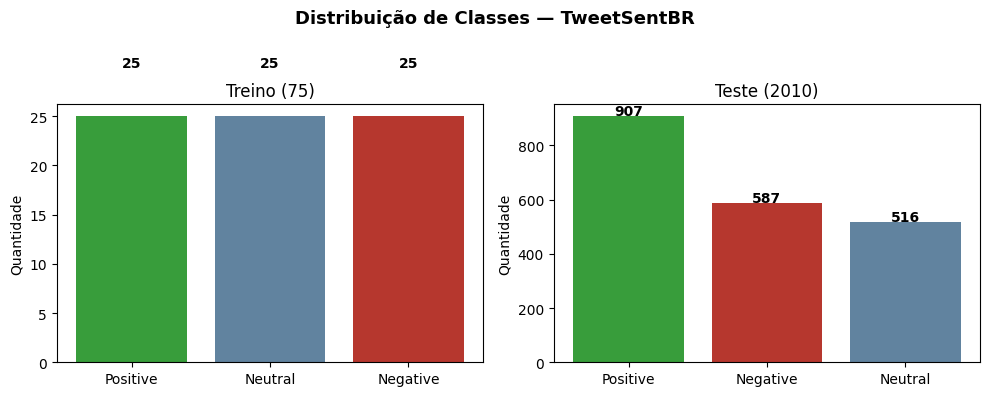

In [4]:
df_train = pd.DataFrame(dataset["train"])
df_test  = pd.DataFrame(dataset["test"])

print("----- TREINO -----")
print(df_train["label"].value_counts())
print("\n----- TESTE -----")
print(df_test["label"].value_counts())

# Distribuição visual
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (df, titulo) in zip(axes, [(df_train, "Treino (75)"), (df_test, "Teste (2010)")]):
    contagem = df["label"].value_counts()
    cores = {"Positive": "#389D3B", "Negative": "#B6372E", "Neutral": "#61839F"}
    ax.bar(contagem.index, contagem.values, color=[cores[l] for l in contagem.index])
    ax.set_title(titulo)
    ax.set_ylabel("Quantidade")
    for i, v in enumerate(contagem.values):
        ax.text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.suptitle("Distribuição de Classes — TweetSentBR", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [5]:
LABEL_MAP = {
    # pysentimiento / robertuito
    "POS": "Positive",
    "NEG": "Negative",
    "NEU": "Neutral",
    # XLM-RoBERTa Twitter (cardiffnlp)
    "positive": "Positive",
    "negative": "Negative",
    "neutral":  "Neutral",
    # BERTimbau (após fine-tune retorna 0,1,2 ou os nomes abaixo)
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive",
}

# Labels verdadeiros do dataset (ground truth)
y_true = df_test["label"].tolist()

print("----- Mapeamento configurado ✅ -----")
print(f"   Classes únicas no teste: {sorted(df_test['label'].unique())}")
print(f"   Total de amostras:       {len(y_true)}")

----- Mapeamento configurado ✅ -----
   Classes únicas no teste: ['Negative', 'Neutral', 'Positive']
   Total de amostras:       2010


##### 04. Testando Modelos

4.1. Modelo 1: XLM-RoBERTa Twitter (CardiffNLP)

In [7]:
from transformers import pipeline
import time

print("--- Carregando Modelo 01: cardiffnlp/twitter-xlm-roberta-base-sentiment... ---")

modelo1_pipeline = pipeline(
    task="sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=0 if torch.cuda.is_available() else -1,  # GPU se disponível
    truncation=True,
    max_length=512
)

print("--- Modelo 01 Carregado ✅ ---")

print("--- Rodando inferência nas 2010 amostras... ---")

textos = df_test["sentence"].tolist()

inicio = time.time()
resultados_m1_raw = modelo1_pipeline(textos, batch_size=32)
tempo_m1 = time.time() - inicio

# Mapear labels para o padrão do dataset
y_pred_m1 = [LABEL_MAP.get(r["label"], r["label"]) for r in resultados_m1_raw]

# --- Métricas ---
print(f"\n{'='*50}")
print("RESULTADOS — Modelo 1: XLM-RoBERTa Twitter")
print(f"{'='*50}")
print(f"--- Tempo total de inferência: {tempo_m1:.1f}s ---")
print(f"--- Velocidade média:          {tempo_m1/len(textos)*1000:.1f} ms/texto\n ---")

print(classification_report(y_true, y_pred_m1, digits=3))

f1_m1 = f1_score(y_true, y_pred_m1, average="macro")
acc_m1 = accuracy_score(y_true, y_pred_m1)
print(f"F1-Macro:  {f1_m1:.4f}")
print(f"Acurácia:  {acc_m1:.4f}")

--- Carregando Modelo 01: cardiffnlp/twitter-xlm-roberta-base-sentiment... ---


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5837.12it/s]


--- Modelo 01 Carregado ✅ ---
--- Rodando inferência nas 2010 amostras... ---

RESULTADOS — Modelo 1: XLM-RoBERTa Twitter
--- Tempo total de inferência: 178.2s ---
--- Velocidade média:          88.7 ms/texto
 ---
              precision    recall  f1-score   support

    Negative      0.665     0.826     0.737       587
     Neutral      0.573     0.647     0.608       516
    Positive      0.900     0.692     0.783       907

    accuracy                          0.720      2010
   macro avg      0.713     0.722     0.709      2010
weighted avg      0.747     0.720     0.724      2010

F1-Macro:  0.7092
Acurácia:  0.7199


4.2. Modelo 2: BERTimbau (DistilBERT Multilingual Sentiment)

In [8]:
print("--- Carregando Modelo 02: lxyuan/distilbert-base-multilingual-cased-sentiments-student... ---")

modelo2_pipeline = pipeline(
    task = "sentiment-analysis",
    model = "lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    tokenizer = "lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    device = 0 if torch.cuda.is_available() else -1,
    truncation = True,
    max_length = 512
)

print("--- Modelo 02 carregado ✔️ ---")
print("--- Rodando inferência nas 2010 amostras... ---")

inicio = time.time()
resultados_m2_raw = modelo2_pipeline(textos, batch_size = 32)
tempo_m2 = time.time() - inicio
y_pred_m2 = [LABEL_MAP.get(r["label"], r["label"]) for r in resultados_m2_raw]

print(f"\n{'='*50}")
print("--- RESULTADOS – Modelo 2: DistilBERT Multilingual Sentiment")
print(f"{'='*50}")
print("--- Tempo total de inferência: {tempo_m2:.1f}s")
print("--- Velocidade média: {tempo_m2/len(textos)*1000:.1f} ms/textos\n")

print(classification_report(y_true, y_pred_m2, digits= 3))
f1_m2 = f1_score(y_true, y_pred_m2, average= "macro")
acc_m2 = accuracy_score(y_true, y_pred_m2)

print(f"F1-Macro: {f1_m2: .4f}")
print(f"Acurácia: {acc_m2: .4f}")

--- Carregando Modelo 02: lxyuan/distilbert-base-multilingual-cased-sentiments-student... ---


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2509.00it/s]


--- Modelo 02 carregado ✔️ ---
--- Rodando inferência nas 2010 amostras... ---

--- RESULTADOS – Modelo 2: DistilBERT Multilingual Sentiment
--- Tempo total de inferência: {tempo_m2:.1f}s
--- Velocidade média: {tempo_m2/len(textos)*1000:.1f} ms/textos

              precision    recall  f1-score   support

    Negative      0.412     0.659     0.507       587
     Neutral      0.395     0.062     0.107       516
    Positive      0.586     0.639     0.612       907

    accuracy                          0.497      2010
   macro avg      0.464     0.454     0.409      2010
weighted avg      0.486     0.497     0.452      2010

F1-Macro:  0.4086
Acurácia:  0.4970


4.3. Modelo 03.A: Pysentimiento (Sem Batch)

In [ ]:
%pip install pysentimiento --quiet

from pysentimiento import create_analyzer
from collections import Counter

print("--- Carregando Modelo 3: pysentimiento (RoBERTuito PT-BR)...---")
analyzer_sent = create_analyzer(task="sentiment", lang="pt")
analyzer_emot = create_analyzer(task="emotion",   lang="pt")
print("--- Modelo 3 carregado ✅---\n")

print("--- Rodando inferência SEM batch (texto por texto)...---")

inicio_nb = time.time()

y_pred_nb  = []
emocoes_nb = []

for i, texto in enumerate(textos):
    res_sent = analyzer_sent.predict(texto)
    res_emot = analyzer_emot.predict(texto)
    y_pred_nb.append(LABEL_MAP.get(res_sent.output, res_sent.output))
    emocoes_nb.append(res_emot.output)

    if (i + 1) % 200 == 0:
        decorrido = time.time() - inicio_nb
        estimativa = (decorrido / (i + 1)) * (len(textos) - i - 1)
        print(f"   [{i+1}/{len(textos)}] {decorrido:.0f}s decorridos | ~{estimativa:.0f}s restantes")

tempo_nb = time.time() - inicio_nb

print(f"\n{'='*50}")
print("--- RESULTADOS Modelo 03.A — pysentimiento SEM batch ---")
print(f"{'='*50}")
print(f"--- Tempo total:    {tempo_nb:.1f}s ({tempo_nb/60:.1f} min) ---")
print(f"--- ms/texto:       {tempo_nb/len(textos)*1000:.1f}\n ---")

print(classification_report(y_true, y_pred_nb, digits=3))

f1_nb  = f1_score(y_true, y_pred_nb, average="macro")
acc_nb = accuracy_score(y_true, y_pred_nb)
print(f"F1-Macro:  {f1_nb:.4f}")
print(f"Acurácia:  {acc_nb:.4f}")


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
--- Carregando Modelo 3: pysentimiento (RoBERTuito PT-BR)...---


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 17425.69it/s]


--- Modelo 3 carregado ✅---

--- Rodando inferência SEM batch (texto por texto)...---
   [200/2010] 44s decorridos | ~402s restantes
   [400/2010] 97s decorridos | ~389s restantes
   [600/2010] 149s decorridos | ~351s restantes
   [800/2010] 206s decorridos | ~312s restantes
   [1000/2010] 258s decorridos | ~261s restantes
   [1200/2010] 308s decorridos | ~208s restantes
   [1400/2010] 357s decorridos | ~156s restantes
   [1600/2010] 452s decorridos | ~116s restantes
   [1800/2010] 508s decorridos | ~59s restantes
   [2000/2010] 564s decorridos | ~3s restantes

--- RESULTADOS Modelo 03 — pysentimiento SEM batch ---
--- Tempo total:    567.4s (9.5 min) ---
--- ms/texto:       282.3
 ---
              precision    recall  f1-score   support

    Negative      0.922     0.906     0.914       587
     Neutral      0.809     0.855     0.831       516
    Positive      0.934     0.914     0.924       907

    accuracy                          0.897      2010
   macro avg      0.888     0.892

4.3. Modelo 03.B: Pysentimiento (com Batch manual)

In [ ]:
BATCH_SIZE = 32

print(f"--- Rodando inferência COM batch (tamanho= {BATCH_SIZE})...---")

inicio_b = time.time()

y_pred_b  = []
emocoes_b = []

for i in range(0, len(textos), BATCH_SIZE):
    batch = textos[i : i + BATCH_SIZE]

    res_sent_batch = analyzer_sent.predict(batch)
    res_emot_batch = analyzer_emot.predict(batch)

    for rs, re in zip(res_sent_batch, res_emot_batch):
        y_pred_b.append(LABEL_MAP.get(rs.output, rs.output))
        emocoes_b.append(re.output)

    if (i // BATCH_SIZE + 1) % 10 == 0:
        decorrido = time.time() - inicio_b
        amostras_feitas = min(i + BATCH_SIZE, len(textos))
        estimativa = (decorrido / amostras_feitas) * (len(textos) - amostras_feitas)
        print(f"   [{amostras_feitas}/{len(textos)}] ⏱️ {decorrido:.0f}s | ~{estimativa:.0f}s restantes")

tempo_b = time.time() - inicio_b

print(f"\n{'='*50}")
print("--- RESULTADOS Modelo 03.B — pysentimiento COM batch ---")
print(f"{'='*50}")
print(f"--- Tempo total:    {tempo_b:.1f}s ({tempo_b/60:.1f} min) ---")
print(f"--- ms/texto:       {tempo_b/len(textos)*1000:.1f}\n ---")

print(classification_report(y_true, y_pred_b, digits=3))

f1_b  = f1_score(y_true, y_pred_b, average="macro")
acc_b = accuracy_score(y_true, y_pred_b)
print(f"--- F1-Macro:  {f1_b:.4f} ---")
print(f"--- Acurácia:  {acc_b:.4f} ---")

--- Rodando inferência COM batch (tamanho= 32)...---


Map: 100%|██████████| 32/32 [00:00<00:00, 1049.12 examples/s]


   [320/2010] ⏱️ 275s | ~1454s restantes


Map: 100%|██████████| 32/32 [00:00<00:00, 1769.00 examples/s]


   [640/2010] ⏱️ 688s | ~1472s restantes


...

   [1600/2010] ⏱️ 1416s | ~363s restantes


Map: 100%|██████████| 32/32 [00:00<00:00, 1447.58 examples/s]


   [1920/2010] ⏱️ 1665s | ~78s restantes


Map: 100%|██████████| 26/26 [00:00<00:00, 1990.69 examples/s]



--- RESULTADOS Modelo 03.B — pysentimiento COM batch ---
--- Tempo total:    1736.5s (28.9 min) ---
--- ms/texto:       863.9
 ---
              precision    recall  f1-score   support

    Negative      0.922     0.906     0.914       587
     Neutral      0.809     0.855     0.831       516
    Positive      0.934     0.914     0.924       907

    accuracy                          0.897      2010
   macro avg      0.888     0.892     0.890      2010
weighted avg      0.898     0.897     0.897      2010

--- F1-Macro:  0.8897 ---
--- Acurácia:  0.8965 ---


##### 5. Análise e Comparação dos Modelos

Neste capítulo serão apresentados os resultados do benchmark comparativo entre modelos avaliado em configuração zero-shot sobre o dataset TweetSentBR (2.010 amostras de teste em português brasileiro).

As métricas utilizadas foram **F1 Macro, Acurácia, Precision** e **Recall** por classe, além de latência de inferência, considerando que o produto final (Opinate) requer respostas em tempo próximo ao real durante debates.

**5.1 Trade-off: pysentimiento com e sem batch**

O modelo pysentimiento (RoBERTuito) foi avaliado em duas configurações de inferência
com o objetivo de identificar a estratégia mais eficiente para uso em produção:
processamento texto a texto (sem batch) e processamento em lotes de 32 amostras
(batch = 32).

| Configuração | Tempo Total | ms/texto | F1-Macro | Acurácia |
|---|---|---|---|---|
| Sem batch    | 567.4s (9.5 min) | 282.3 ms | 0.8897 | 0.8965 |
| Com batch=32 | 1736.5s (28.9 min) | 863.9 ms | 0.8897 | 0.8965 |

As métricas de qualidade foram **idênticas** nas duas configurações — F1-Macro de
0.8897 e acurácia de 89.65% —, confirmando que o processamento em batch não altera
a matemática interna do modelo, apenas a estratégia de execução.

O resultado de latência, no entanto, foi **contrário ao esperado**: a configuração
sem batch foi aproximadamente **3x mais rápida** que a com batch = 32 (567s vs. 1736s).
Esse comportamento se explica pelo fato de o pysentimiento já implementar internamente
sua própria lógica de paralelismo sobre o RoBERTuito. A imposição de um batch externo
adiciona overhead de serialização e gerenciamento de memória que supera qualquer
ganho potencial de paralelismo, tornando a abordagem contraproducente neste contexto.

> **Conclusão 5.1:** Para o pysentimiento, a configuração sem batch é superior em
> eficiência operacional sem qualquer custo em qualidade. Em ambiente de produção,
> recomenda-se inferência direta (sem batch externo), com possível paralelismo
> gerenciado pela própria biblioteca.


**5.2 Comparativo Geral dos Modelos**

A tabela a seguir consolida os resultados dos três modelos avaliados, utilizando
a configuração sem batch para o pysentimiento, por ser a mais eficiente conforme
demonstrado na seção 5.1.

| Modelo | F1-Macro | Acurácia | F1 Negative | F1 Neutral | F1 Positive | ms/texto |
|---|---|---|---|---|---|---|
| XLM-RoBERTa Twitter (CardiffNLP) | 0.7092 | 0.7199 | 0.737 | 0.608 | 0.783 | 109.9 ms |
| DistilBERT Multilingual | 0.4086 | 0.4970 | 0.507 | 0.107 | 0.612 | ~65 ms |
| pysentimiento — RoBERTuito | **0.8897** | **0.8965** | **0.914** | **0.831** | **0.924** | 282.3 ms |

### Análise por classe

**Negative:** a classe mais crítica para o domínio político, onde errar um comentário
hostil classificando-o como neutro representa o maior risco de falha do produto.
O pysentimiento obteve F1 de 0.914, contra 0.737 do XLM-RoBERTa e 0.507 do DistilBERT.
A superioridade é expressiva e consistente em precision e recall, indicando que o
modelo não apenas identifica negatividade quando presente, como raramente a confunde
com outras classes.

**Neutral:** historicamente a classe mais difícil em análise de sentimentos, por sua
natureza ambígua. O DistilBERT praticamente falhou nessa classe (F1 = 0.107, recall
de 0.062), colapsando a maioria das predições em Positive e Negative. O XLM-RoBERTa
obteve desempenho razoável (F1 = 0.608). O pysentimiento novamente liderou com F1
de 0.831, resultado notável para zero-shot.

**Positive:** todos os modelos tiveram desempenho relativamente melhor nessa classe,
reflexo do desbalanceamento do dataset (907 amostras positivas vs. 516 neutras).
O pysentimiento obteve F1 de 0.924, seguido pelo XLM-RoBERTa com 0.783.

### Análise de latência

Em termos de velocidade, o DistilBERT é o mais eficiente (~65 ms/texto), seguido
pelo XLM-RoBERTa (109.9 ms) e pelo pysentimiento (282.3 ms). Contudo, a diferença
de latência entre os modelos deve ser interpretada à luz da diferença de qualidade:
o pysentimiento entrega um F1-Macro 0.18 pontos acima do XLM-RoBERTa e 0.48 acima
do DistilBERT, com uma latência apenas 2.6x maior que o mais rápido. Para uma
plataforma de debates acadêmicos, onde as análises não precisam ocorrer em
milissegundos, mas sim acompanhar o ritmo de postagens, **282 ms por texto** é
plenamente aceitável.

**5.3 Seleção do Modelo**

> **Modelo eleito para fine-tuning: pysentimiento (RoBERTuito)**

O pysentimiento foi o modelo com melhor desempenho em todas as métricas avaliadas,
em todas as classes, em configuração zero-shot, sem qualquer adaptação ao domínio
político. F1-Macro de 0.8897 e acurácia de 89.65% sobre 2.010 amostras reais em
português brasileiro representam um ponto de partida excepcionalmente sólido para
o fine-tuning planejado na Sprint 4.

Dois aspectos adicionais reforçam a escolha. Primeiro, o modelo oferece nativamente
detecção de emoções (alegria, raiva, medo, tristeza, entre outras), camada analítica
relevante para mapear perfis políticos na Opinate para além da polaridade simples.
Segundo, sua arquitetura baseada no RoBERTuito (treinado sobre 500 milhões de
tweets em espanhol e português) confere robustez a gírias, ironia e linguagem
informal, exatamente o registro predominante em debates online.

**Limitações identificadas:**

- Latência de 282 ms/texto pode ser um gargalo em cenários de alto volume simultâneo,
  exigindo estratégia de fila ou processamento assíncrono na integração com o produto.
- O modelo foi treinado predominantemente em tweets gerais; o domínio político-acadêmico
  específico da Opinate ainda não foi coberto, justificando o fine-tuning com dados
  eleitorais e sintéticos planejado para a próxima sprint.
- Ausência de batch nativo eficiente limita escalabilidade horizontal sem ajustes
  de infraestrutura.

**Próximos passos — Sprint 4:**

- Fine-tuning do pysentimiento com dados do domínio político (Tweet_Eleições_2022
  + base sintética Opinate)
- Reavaliação das métricas pós fine-tuning e comparação com os resultados zero-shot
  aqui obtidos como linha de base
- Integração do modelo ajustado com o pipeline do produto final via API REST,
  retornando label de sentimento, score de confiança e emoção detectada por postagem